In [454]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv(r"D:\project\CN\neuro_data.csv")
df.head(10)

,neuro_id,age_group,frequency,n_trials,spike_count,rat_id
0,1,adult,13000,20,3,20240608
1,1,adult,14000,20,6,20240608
2,1,adult,15000,20,8,20240608
3,1,adult,16000,20,18,20240608
4,1,adult,17000,20,12,20240608
5,1,adult,18000,20,4,20240608
6,1,adult,19000,20,1,20240608
7,1,adult,20000,20,1,20240608
8,2,adult,4000,20,4,20240608
9,2,adult,5000,20,7,20240608


In [455]:
df["firing_rate"] = df["spike_count"] / df["n_trials"]
print(df.head())

   neuro_id age_group  frequency  n_trials  spike_count    rat_id  firing_rate
0         1     adult      13000        20            3  20240608         0.15
1         1     adult      14000        20            6  20240608         0.30
2         1     adult      15000        20            8  20240608         0.40
3         1     adult      16000        20           18  20240608         0.90
4         1     adult      17000        20           12  20240608         0.60


In [456]:
df.isna().sum()

neuro_id       0
age_group      0
frequency      0
n_trials       0
spike_count    0
rat_id         0
firing_rate    0
dtype: int64

In [457]:
print(df.columns.tolist())

['neuro_id', 'age_group', 'frequency', 'n_trials', 'spike_count', 'rat_id', 'firing_rate']


In [458]:
df = df.sort_values(["neuro_id", "frequency"])

In [459]:
df["n_trials"].unique()

array([20])

In [460]:
df.head()

,neuro_id,age_group,frequency,n_trials,spike_count,rat_id,firing_rate
0,1,adult,13000,20,3,20240608,0.15
1,1,adult,14000,20,6,20240608,0.30
2,1,adult,15000,20,8,20240608,0.40
3,1,adult,16000,20,18,20240608,0.90
4,1,adult,17000,20,12,20240608,0.60


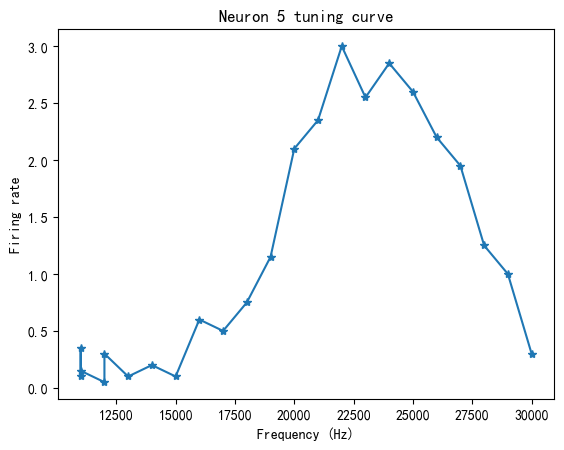

In [461]:
import matplotlib.pyplot as plt

n = df[df["neuro_id"] == 119]
#底下的标题id应该随着上面的数字变化

plt.plot(n["frequency"], n["firing_rate"], marker="*")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Firing rate")
plt.title("Neuron 5 tuning curve")
plt.show()

总体标准差均值: 0.3257318773988374
总体标准差的标准差: 0.1295310447165689
筛选阈值: 0.7143250115485441
方差过大的 neuron: neuro_id
5      0.769179
99     0.747635
119    1.041904
213    1.011388
Name: firing_rate, dtype: float64


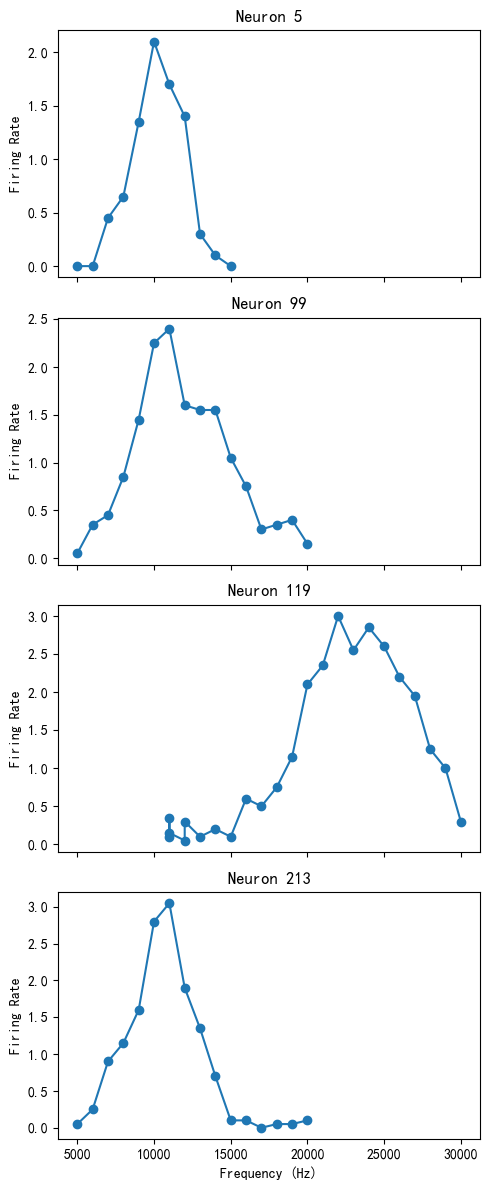

In [462]:
#为何这种方法可以筛选异常神经元？
import pandas as pd

# 假设 df 已经包含 'neuro_id' 和 'firing_rate'

# 1️⃣ 计算每个 neuron 的 firing rate 标准差
neuron_std = df.groupby("neuro_id")["firing_rate"].std()

# 2️⃣ 计算总体均值和标准差
mean_std = neuron_std.mean()
std_std = neuron_std.std()

# 3️⃣ 设置阈值
threshold = mean_std + 3 * std_std

print("总体标准差均值:", mean_std)
print("总体标准差的标准差:", std_std)
print("筛选阈值:", threshold)

# 4️⃣ 找出超过阈值的 neuron
high_var_neurons = neuron_std[neuron_std > threshold]
print("方差过大的 neuron:", high_var_neurons)

high_disp_neurons = neuron_std[neuron_std > threshold].index.tolist()

n_neurons = len(high_disp_neurons)
fig, axes = plt.subplots(n_neurons, 1, figsize=(5, 3*n_neurons), sharex=True)

if n_neurons == 1:
    axes = [axes]  # 保证 axes 可迭代

for ax, neuron_id in zip(axes, high_disp_neurons):
    n = df[df["neuro_id"] == neuron_id]
    ax.plot(n["frequency"], n["firing_rate"], marker='o', color='tab:blue')
    ax.set_ylabel("Firing Rate")
    ax.set_title(f"Neuron {neuron_id}")

axes[-1].set_xlabel("Frequency (Hz)")
plt.tight_layout()
plt.show()

In [463]:
zero_neurons = df.groupby("neuro_id")["firing_rate"].max()
zero_neurons = zero_neurons[zero_neurons == 0]
print(zero_neurons)

Series([], Name: firing_rate, dtype: float64)


In [464]:
import pandas as pd

# 假设 df 是你的长格式数据
# 如果 neuron_id 列不存在，用 rat_id 代替 neuron
df['total_fr'] = df.groupby('neuro_id')['firing_rate'].transform('sum')
df['normalized_fr'] = df['firing_rate'] / df['total_fr']
# 查看结果
print(df.head())

   neuro_id age_group  frequency  n_trials  spike_count    rat_id  \
0         1     adult      13000        20            3  20240608   
1         1     adult      14000        20            6  20240608   
2         1     adult      15000        20            8  20240608   
3         1     adult      16000        20           18  20240608   
4         1     adult      17000        20           12  20240608   

   firing_rate  total_fr  normalized_fr  
0         0.15      2.65       0.056604  
1         0.30      2.65       0.113208  
2         0.40      2.65       0.150943  
3         0.90      2.65       0.339623  
4         0.60      2.65       0.226415  


In [465]:
# 每个 neuron 的 BF：frequency 对应最大 spike_count
df['BF'] = df.groupby(['rat_id','neuro_id'])['frequency'] \
             .transform(lambda x: x.iloc[np.argmax(df.loc[x.index, 'spike_count'])])

# 检查列
print(df.columns)
df.head(25)

Index(['neuro_id', 'age_group', 'frequency', 'n_trials', 'spike_count',
       'rat_id', 'firing_rate', 'total_fr', 'normalized_fr', 'BF'],
      dtype='object')


,neuro_id,age_group,frequency,n_trials,spike_count,rat_id,firing_rate,total_fr,normalized_fr,BF
0,1,adult,13000,20,3,20240608,0.15,2.65,0.056604,16000
1,1,adult,14000,20,6,20240608,0.30,2.65,0.113208,16000
2,1,adult,15000,20,8,20240608,0.40,2.65,0.150943,16000
3,1,adult,16000,20,18,20240608,0.90,2.65,0.339623,16000
4,1,adult,17000,20,12,20240608,0.60,2.65,0.226415,16000
5,1,adult,18000,20,4,20240608,0.20,2.65,0.075472,16000
6,1,adult,19000,20,1,20240608,0.05,2.65,0.018868,16000
7,1,adult,20000,20,1,20240608,0.05,2.65,0.018868,16000
8,2,adult,4000,20,4,20240608,0.20,2.20,0.090909,6000
9,2,adult,5000,20,7,20240608,0.35,2.20,0.159091,6000


In [466]:
# 找出不在 6000-24000 Hz 的 neuron
out_of_range_neurons = width_df[(width_df['BF'] < 6000) | (width_df['BF'] > 24000)]
print("不在 6000-24000 Hz 的 neuron：")
print(out_of_range_neurons[['neuron_id','BF','age_group','CF','Width']])

不在 6000-24000 Hz 的 neuron：
Empty DataFrame
Columns: [neuron_id, BF, age_group, CF, Width]
Index: []


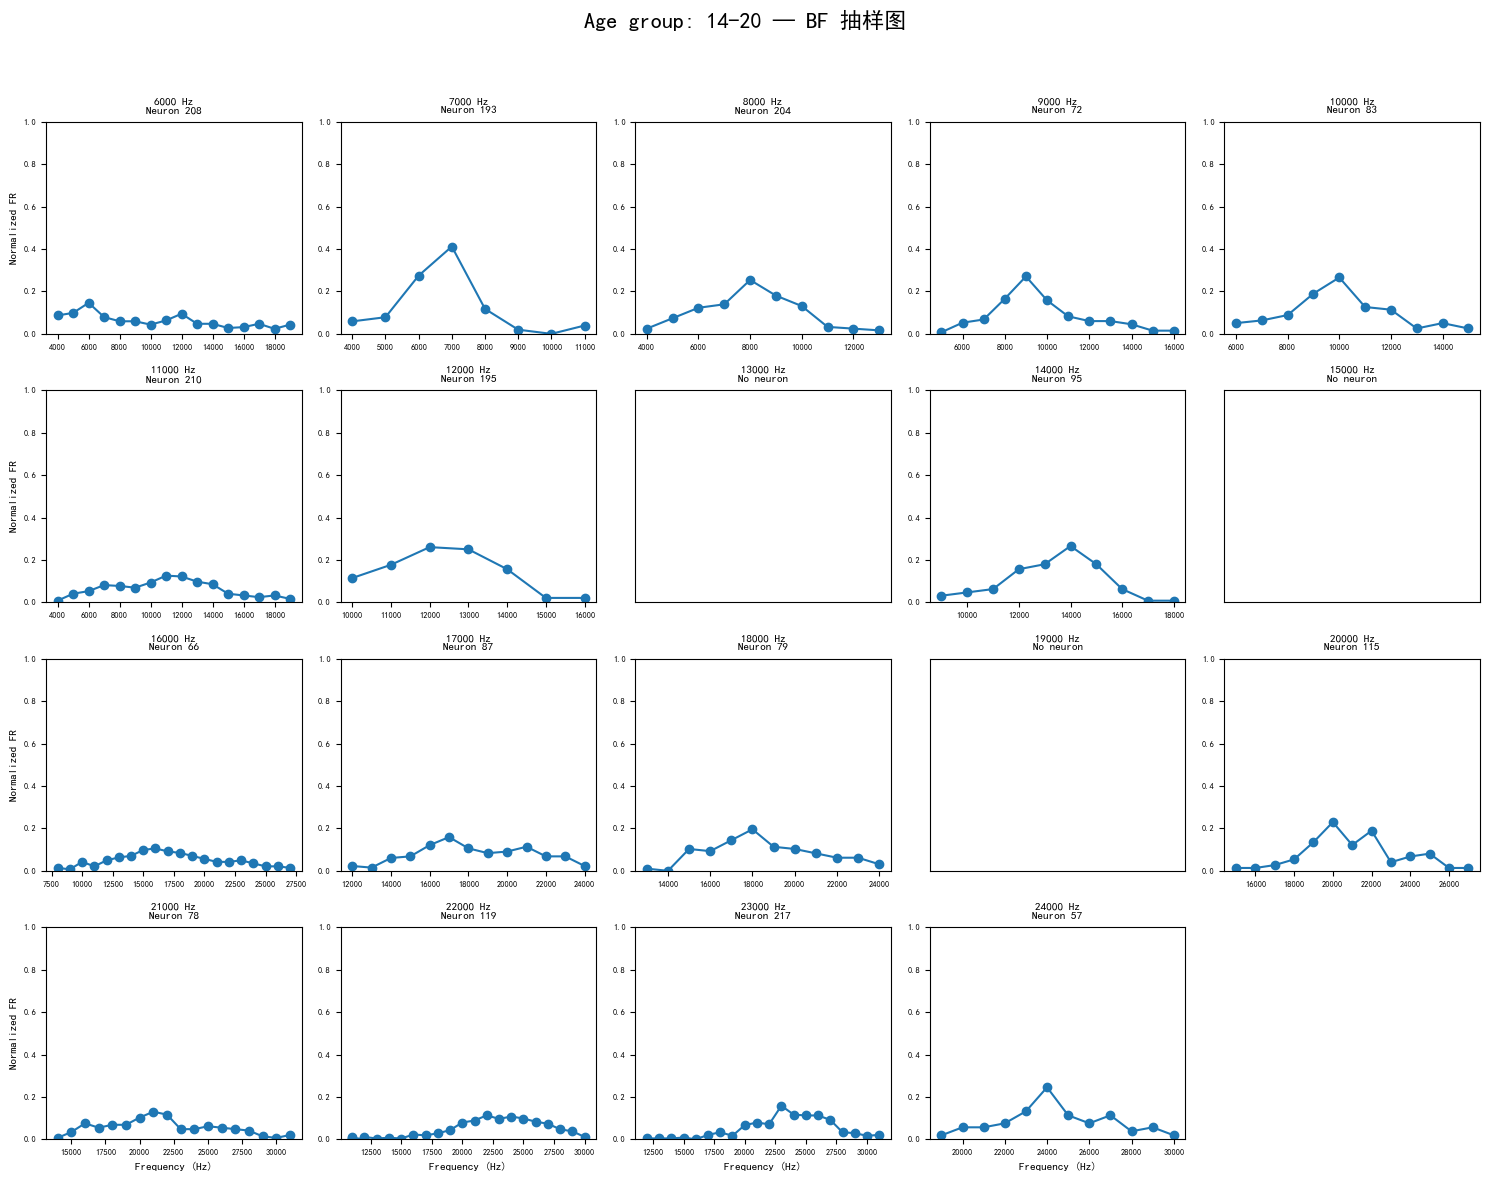

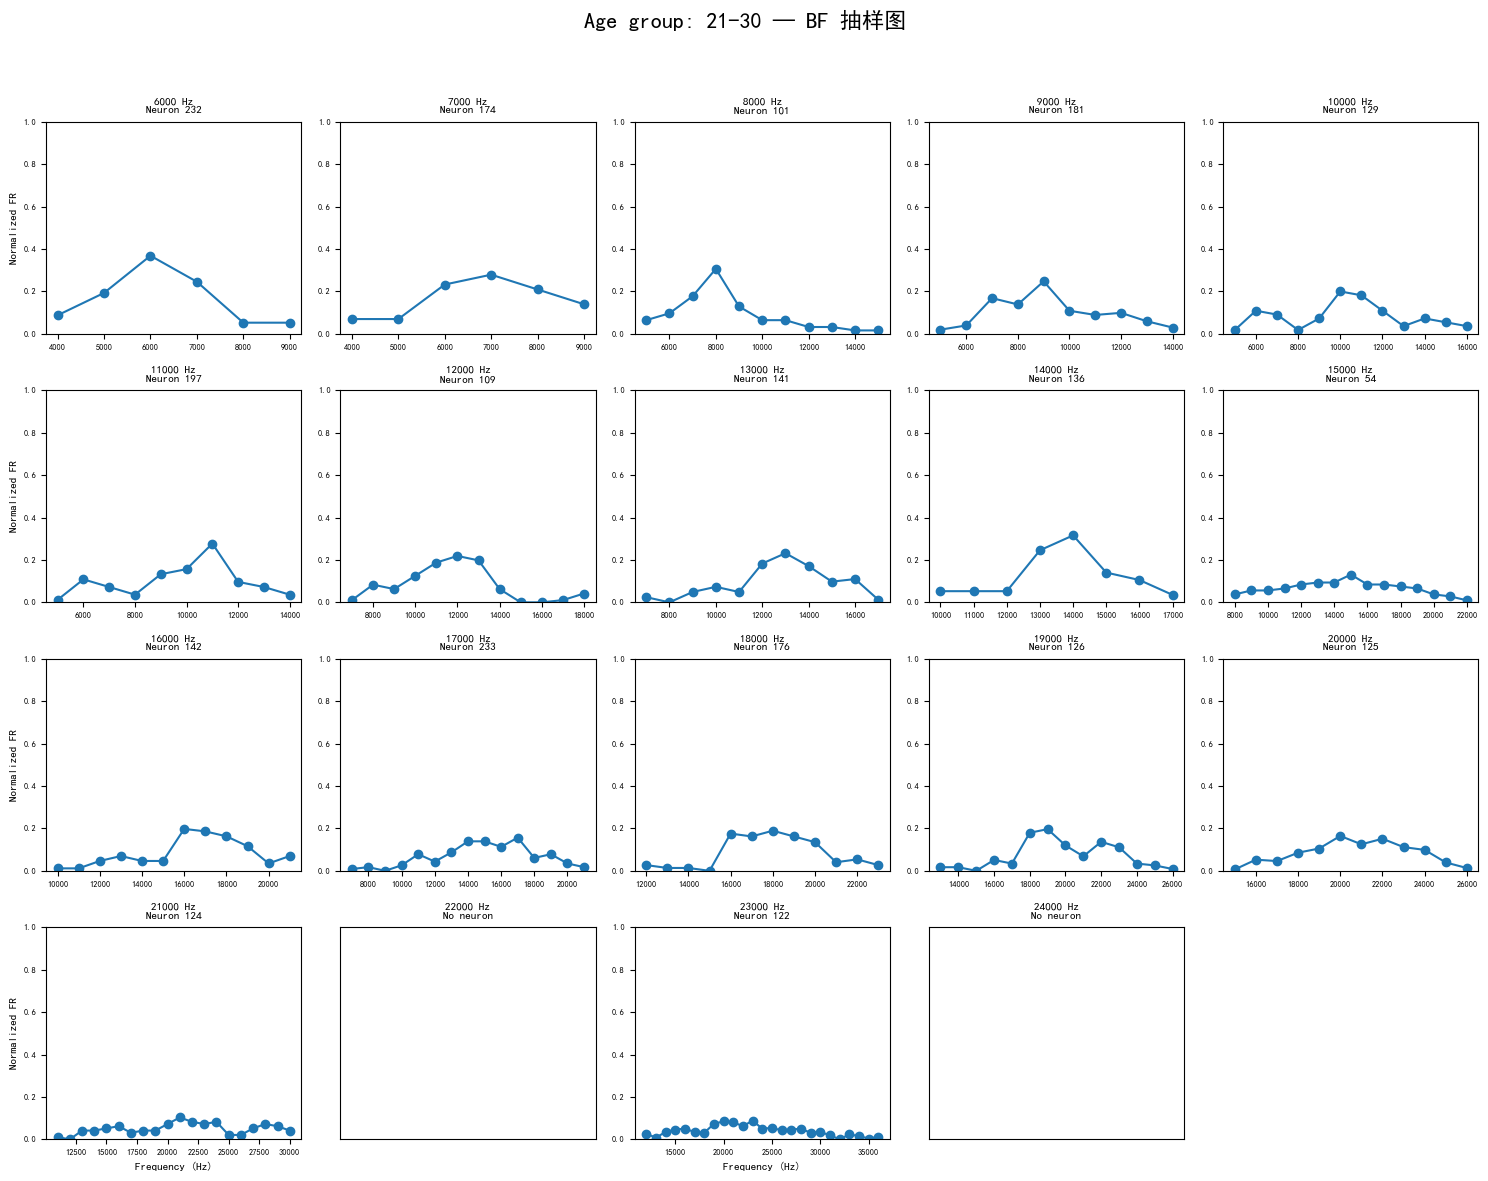

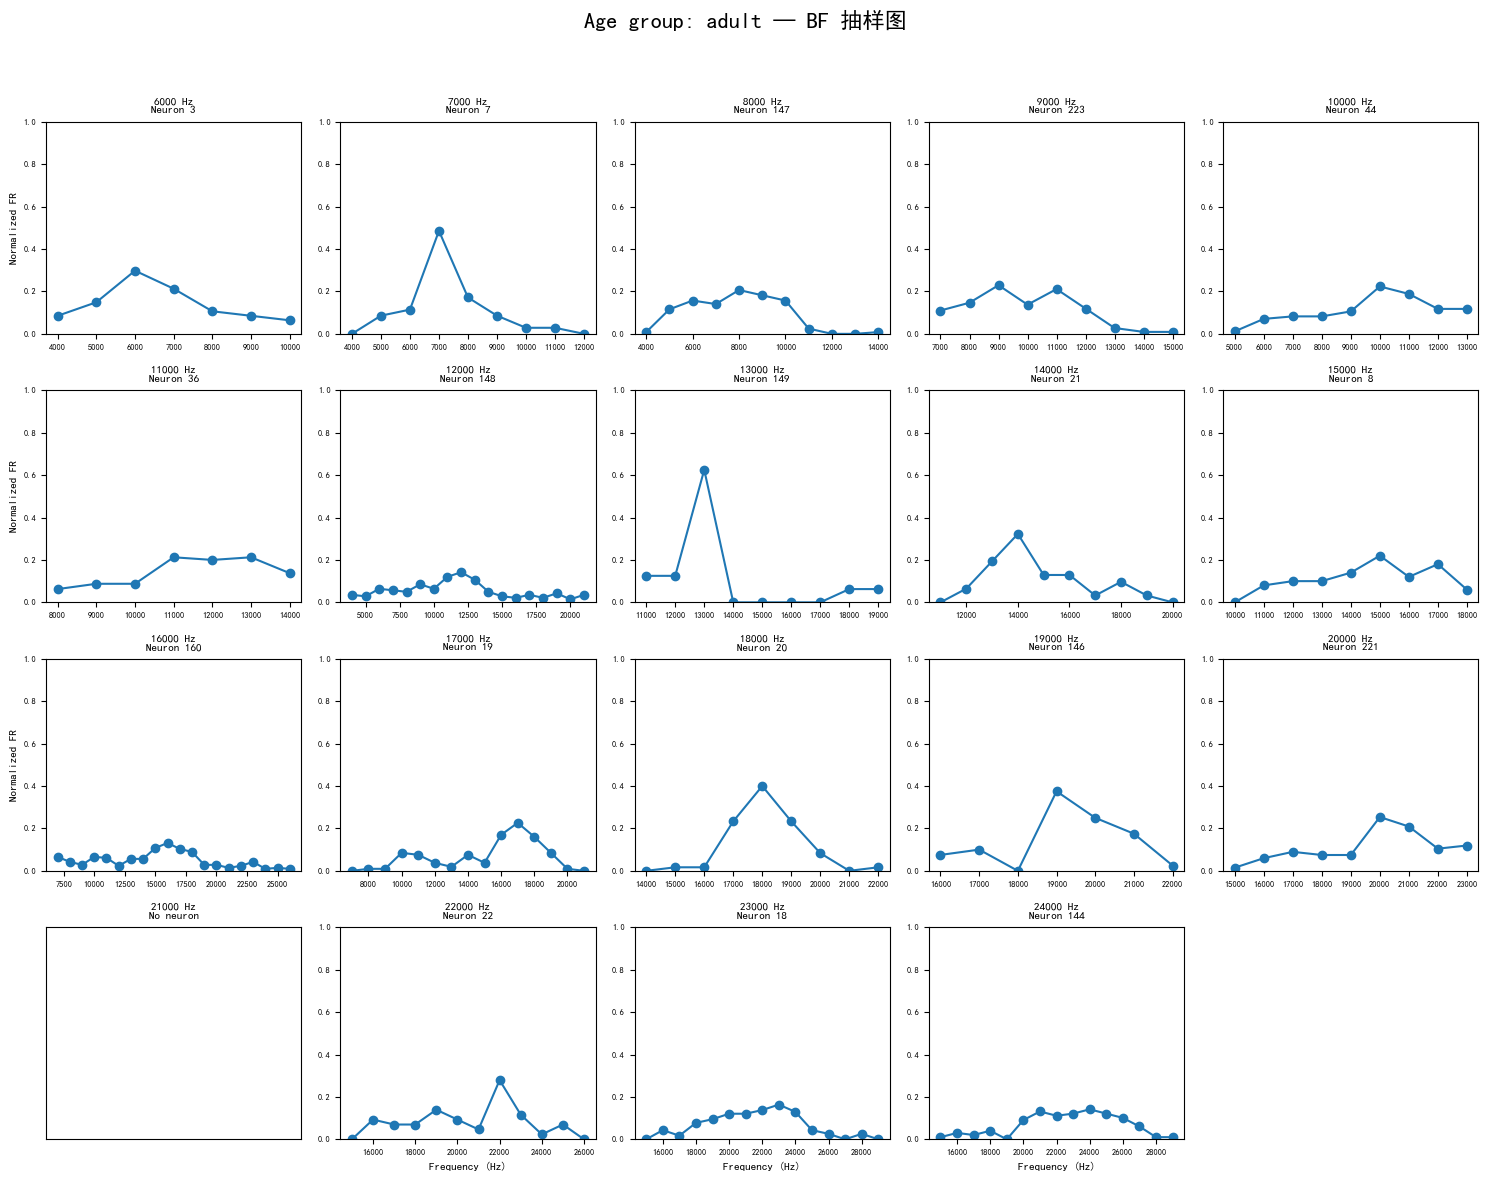

In [467]:
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei']
matplotlib.rcParams['axes.unicode_minus'] = False
import numpy as np
import matplotlib.pyplot as plt

bf_bins = np.arange(6000, 24001, 1000)
selected_neurons = []  # 存储被选中的 neuron_id 和 neuron_df

for age, age_df in df.groupby('age_group'):
    # ---------------------------
    # 1️⃣ 每行5个图的 BF 抽样图
    # ---------------------------
    n_cols = 5
    n_rows = int(np.ceil(len(bf_bins)/n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*3, n_rows*3))
    fig.suptitle(f"Age group: {age} — BF 抽样图", fontsize=16)

    selected_neurons = []  # 每个年龄组单独存储 neuron

    for i, bf_target in enumerate(bf_bins):
        row = i // n_cols
        col = i % n_cols
        ax = axes[row, col]

        bf_neurons = age_df[(age_df['BF'] >= bf_target) & (age_df['BF'] < bf_target + 1000)]
        if len(bf_neurons) == 0:
            ax.set_title(f"{bf_target} Hz\nNo neuron", fontsize=8)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_ylim(0,0.6)
            continue

        # 随机抽一个 neuron
        neuron_id = np.random.choice(bf_neurons['neuro_id'].unique())
        neuron_df = bf_neurons[bf_neurons['neuro_id']==neuron_id]

        # 保存 neuron 用于连续图
        selected_neurons.append((neuron_id, neuron_df))

        # 绘制子图
        ax.plot(neuron_df['frequency'], neuron_df['normalized_fr'], marker='o')
        ax.set_ylim(0,1.0)
        ax.set_title(f"{bf_target} Hz\nNeuron {neuron_id}", fontsize=8)
        ax.tick_params(axis='both', which='major', labelsize=6)

        if col==0:
            ax.set_ylabel("Normalized FR", fontsize=8)
        if row==n_rows-1:
            ax.set_xlabel("Frequency (Hz)", fontsize=8)

    # 删除多余的空子图
    total_plots = n_rows * n_cols
    if total_plots > len(bf_bins):
        for j in range(len(bf_bins), total_plots):
            fig.delaxes(axes.flatten()[j])
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()

 

In [468]:
# 筛选 neuron_id = 156 的数据
neuron_156_df = df[df['neuro_id'] == 156]

neuron_156_df



,neuro_id,age_group,frequency,n_trials,spike_count,rat_id,firing_rate,total_fr,normalized_fr,BF
1691,156,adult,4000,20,2,20240620,0.10,4.15,0.024096,10000
1692,156,adult,5000,20,1,20240620,0.05,4.15,0.012048,10000
1693,156,adult,6000,20,6,20240620,0.30,4.15,0.072289,10000
1694,156,adult,7000,20,10,20240620,0.50,4.15,0.120482,10000
1695,156,adult,8000,20,6,20240620,0.30,4.15,0.072289,10000
1696,156,adult,9000,20,16,20240620,0.80,4.15,0.192771,10000
1697,156,adult,10000,20,17,20240620,0.85,4.15,0.204819,10000
1698,156,adult,11000,20,9,20240620,0.45,4.15,0.108434,10000
1699,156,adult,12000,20,13,20240620,0.65,4.15,0.156627,10000
1700,156,adult,13000,20,3,20240620,0.15,4.15,0.036145,10000


In [469]:
import numpy as np
import pandas as pd
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks

# 参数（可调整）
SMOOTH_SIGMA = 1.0
PEAK_HEIGHT_RATIO = 0.2
PEAK_PROM_RATIO = 0.15
MIN_PEAK_DISTANCE_RATIO = 0.1

results = []

for (rat, neuron), group in df.groupby(['rat_id', 'neuro_id']):
    
    # 按频率排序
    group = group.sort_values('frequency')
    
    x = group['frequency'].values
    y = group['firing_rate'].values
    
    if len(y) < 5:
        continue
    
    # 平滑
    y_smooth = gaussian_filter1d(y, sigma=SMOOTH_SIGMA)
    
    # 主峰高度
    main_peak_height = np.max(y_smooth)
    
    # 最小峰距
    min_distance = int(len(y) * MIN_PEAK_DISTANCE_RATIO)
    if min_distance < 1:
        min_distance = 1
    
    peaks, properties = find_peaks(
        y_smooth,
        height=main_peak_height * PEAK_HEIGHT_RATIO,
        prominence=main_peak_height * PEAK_PROM_RATIO,
        distance=min_distance
    )
    
    multi_peak = len(peaks) > 1
    
    results.append({
        'rat_id': rat,
        'neuro_id': neuron,
        'age_group': group['age_group'].iloc[0],
        'n_peaks': len(peaks),
        'multi_peak': multi_peak
    })

peak_df = pd.DataFrame(results)

# 统计每个年龄组多峰比例
summary = peak_df.groupby('age_group')['multi_peak'].mean()

print("各年龄组多峰比例：")
print(summary)

各年龄组多峰比例：
age_group
14-20    0.014085
21-30    0.022222
adult    0.013699
Name: multi_peak, dtype: float64


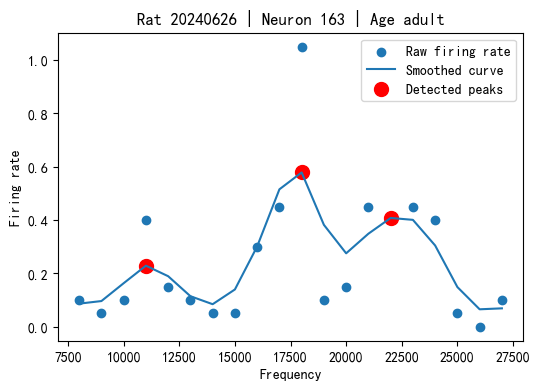

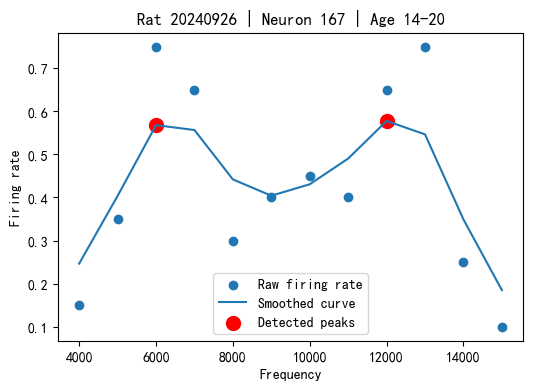

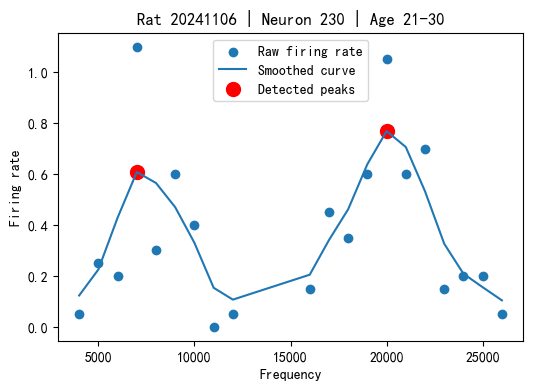

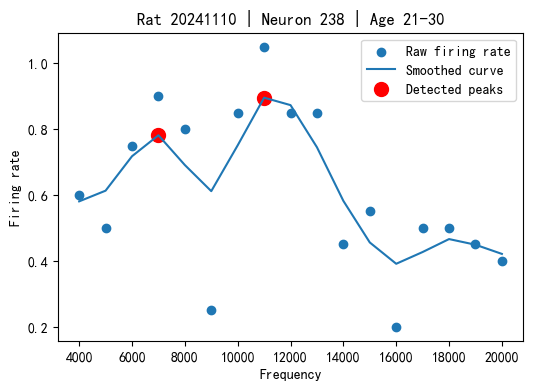

In [470]:
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks
import numpy as np

SMOOTH_SIGMA = 1.0
PEAK_HEIGHT_RATIO = 0.2
PEAK_PROM_RATIO = 0.15
MIN_PEAK_DISTANCE_RATIO = 0.1

# 取 multi-peak neuron 列表
multi_neurons = peak_df[peak_df['multi_peak']]

for _, row in multi_neurons.iterrows():
    
    rat = row['rat_id']
    neuron = row['neuro_id']
    
    group = df[(df['rat_id'] == rat) & 
               (df['neuro_id'] == neuron)].sort_values('frequency')
    
    x = group['frequency'].values
    y = group['firing_rate'].values
    
    y_smooth = gaussian_filter1d(y, sigma=SMOOTH_SIGMA)
    
    main_peak_height = np.max(y_smooth)
    min_distance = max(1, int(len(y) * MIN_PEAK_DISTANCE_RATIO))
    
    peaks, properties = find_peaks(
        y_smooth,
        height=main_peak_height * PEAK_HEIGHT_RATIO,
        prominence=main_peak_height * PEAK_PROM_RATIO,
        distance=min_distance
    )
    
    # 绘图
    plt.figure(figsize=(6,4))
    plt.scatter(x, y, label='Raw firing rate')
    plt.plot(x, y_smooth, label='Smoothed curve')
    plt.scatter(x[peaks], y_smooth[peaks], 
                color='red', s=100, label='Detected peaks')
    
    plt.title(f"Rat {rat} | Neuron {neuron} | Age {group['age_group'].iloc[0]}")
    plt.xlabel("Frequency")
    plt.ylabel("Firing rate")
    plt.legend()
    plt.show()

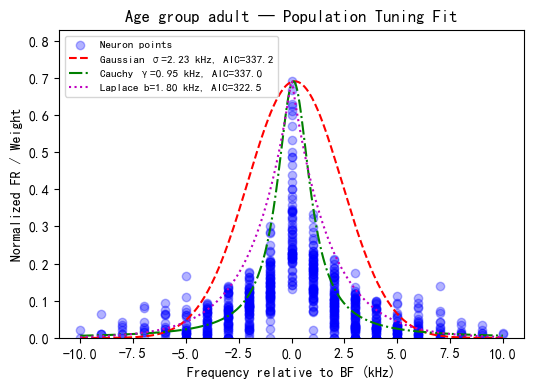

Age group adult: Best model = Laplace
Widths: {'Gaussian σ': np.float64(2.23124713208889), 'Cauchy γ': np.float64(0.9475209970671536), 'Laplace b': np.float64(1.8005414333616405)}



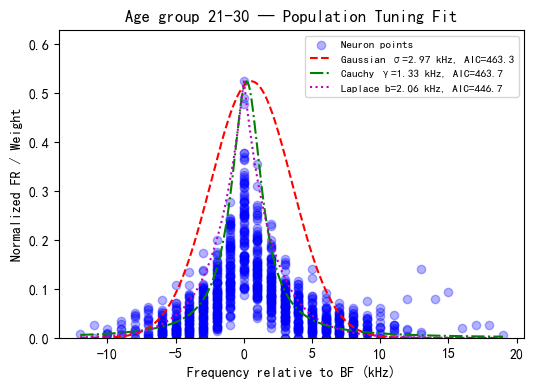

Age group 21-30: Best model = Laplace
Widths: {'Gaussian σ': np.float64(2.9711578144139352), 'Cauchy γ': np.float64(1.3294379993833807), 'Laplace b': np.float64(2.057785486936251)}



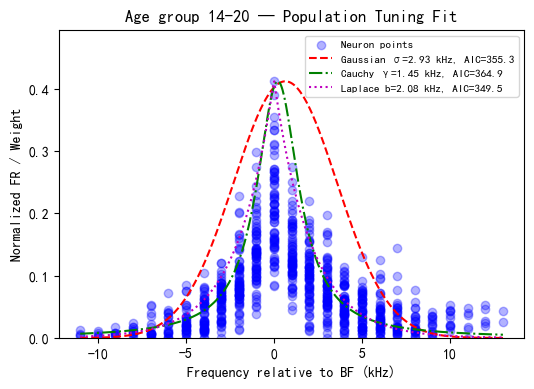

Age group 14-20: Best model = Laplace
Widths: {'Gaussian σ': np.float64(2.930285258330037), 'Cauchy γ': np.float64(1.4502508553498794), 'Laplace b': np.float64(2.07964460759618)}



In [471]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import norm, cauchy, laplace

# 假设 df 已经有 ['age_group','neuro_id','frequency','firing_rate','normalized_fr','BF']

# -----------------------------
# 1️⃣ 数据中心化：以 BF 为基准
# -----------------------------
df['freq_centered_khz'] = (df['frequency'] - df['BF']) / 1000  # 转 kHz

age_groups = df['age_group'].unique()

# -----------------------------
# 2️⃣ 定义负对数似然函数
# -----------------------------
def neg_log_likelihood_gaussian(params, x, weights):
    mu, sigma = params
    if sigma <= 0:
        return np.inf
    pdf = norm.pdf(x, loc=mu, scale=sigma)
    return -np.sum(weights * np.log(pdf + 1e-12))

def neg_log_likelihood_cauchy(params, x, weights):
    x0, gamma = params
    if gamma <= 0:
        return np.inf
    pdf = 1 / (np.pi * gamma * (1 + ((x - x0)/gamma)**2))
    return -np.sum(weights * np.log(pdf + 1e-12))

def neg_log_likelihood_laplace(params, x, weights):
    mu, b = params
    if b <= 0:
        return np.inf
    pdf = 1/(2*b) * np.exp(-np.abs(x-mu)/b)
    return -np.sum(weights * np.log(pdf + 1e-12))

# -----------------------------
# 3️⃣ 拟合与绘图
# -----------------------------
for age in age_groups:
    age_df = df[df['age_group']==age]
    x = age_df['freq_centered_khz'].values
    w = age_df['normalized_fr'].values
    
    # 初始猜测
    mu_init = np.sum(x * w)
    sigma_init = np.sqrt(np.sum(w * (x - mu_init)**2))
    gamma_init = np.sum(w * np.abs(x - mu_init))
    b_init = gamma_init / np.log(2)  # Laplace粗略初始化
    
    # 拟合 Gaussian
    res_gauss = minimize(neg_log_likelihood_gaussian, [mu_init, sigma_init], args=(x,w),
                         bounds=[(x.min(), x.max()), (1e-3, x.max())])
    mu_g, sigma_g = res_gauss.x
    nll_gauss = res_gauss.fun
    aic_gauss = 2*2 + 2*nll_gauss  # 2参数
    
    # 拟合 Cauchy
    res_cauchy = minimize(neg_log_likelihood_cauchy, [mu_init, gamma_init], args=(x,w),
                          bounds=[(x.min(), x.max()), (1e-3, x.max())])
    x0_c, gamma_c = res_cauchy.x
    nll_cauchy = res_cauchy.fun
    aic_cauchy = 2*2 + 2*nll_cauchy
    
    # 拟合 Laplace
    res_lap = minimize(neg_log_likelihood_laplace, [mu_init, b_init], args=(x,w),
                       bounds=[(x.min(), x.max()), (1e-3, x.max())])
    mu_lap, b_lap = res_lap.x
    nll_lap = res_lap.fun
    aic_lap = 2*2 + 2*nll_lap
    
    # -----------------------------
    # 绘图
    # -----------------------------
    plt.figure(figsize=(6,4))
    plt.scatter(x, w, alpha=0.3, color='blue', label='Neuron points')
    
    x_range = np.linspace(x.min(), x.max(), 500)
    # Gaussian
    pdf_g = norm.pdf(x_range, mu_g, sigma_g)
    pdf_g_scaled = pdf_g / pdf_g.max() * w.max()
    plt.plot(x_range, pdf_g_scaled, 'r--', label=f'Gaussian σ={sigma_g:.2f} kHz, AIC={aic_gauss:.1f}')
    
    # Cauchy
    pdf_c = 1 / (np.pi * gamma_c * (1 + ((x_range - x0_c)/gamma_c)**2))
    pdf_c_scaled = pdf_c / pdf_c.max() * w.max()
    plt.plot(x_range, pdf_c_scaled, 'g-.', label=f'Cauchy γ={gamma_c:.2f} kHz, AIC={aic_cauchy:.1f}')
    
    # Laplace
    pdf_l = 1/(2*b_lap) * np.exp(-np.abs(x_range - mu_lap)/b_lap)
    pdf_l_scaled = pdf_l / pdf_l.max() * w.max()
    plt.plot(x_range, pdf_l_scaled, 'm:', label=f'Laplace b={b_lap:.2f} kHz, AIC={aic_lap:.1f}')
    
    plt.xlabel('Frequency relative to BF (kHz)')
    plt.ylabel('Normalized FR / Weight')
    plt.title(f'Age group {age} — Population Tuning Fit')
    plt.legend(fontsize=8)
    plt.ylim(0, w.max()*1.2)
    plt.show()
    
    # 输出宽度参数与最佳模型
    aic_dict = {'Gaussian': aic_gauss, 'Cauchy': aic_cauchy, 'Laplace': aic_lap}
    best_model = min(aic_dict, key=aic_dict.get)
    width_dict = {'Gaussian σ': sigma_g, 'Cauchy γ': gamma_c, 'Laplace b': b_lap}
    
    print(f"Age group {age}: Best model = {best_model}")
    print(f"Widths: {width_dict}\n")

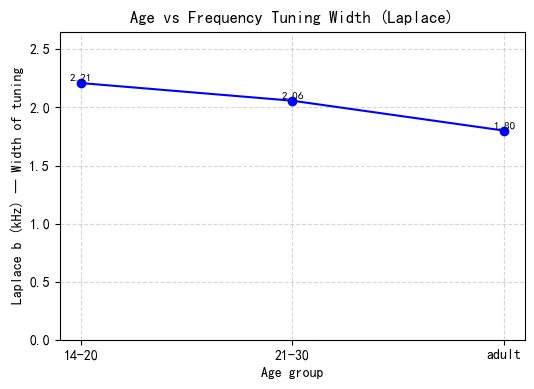

In [472]:
import matplotlib.pyplot as plt

# -----------------------------
# 1️⃣ 汇总宽度数据
# -----------------------------
age_groups = ['14-20', '21-30', 'adult']
laplace_b = [2.210, 2.058, 1.801]  # 你前面计算得到的 Laplace b
# 如果你有每个年龄组 neuron 的宽度，可以换成均值，并加误差条

# -----------------------------
# 2️⃣ 绘制趋势图
# -----------------------------
plt.figure(figsize=(6,4))
plt.plot(age_groups, laplace_b, marker='o', linestyle='-', color='blue')
for i, b in enumerate(laplace_b):
    plt.text(i, b + 0.02, f"{b:.2f}", ha='center', fontsize=8)  # 标出具体值

plt.xlabel('Age group')
plt.ylabel('Laplace b (kHz) — Width of tuning')
plt.title('Age vs Frequency Tuning Width (Laplace)')
plt.ylim(0, max(laplace_b)*1.2)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [473]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize

# 假设 df 已有 ['neuro_id','age_group','frequency','normalized_fr']

# -----------------------------
# 1️⃣ 定义各分布的负对数似然函数
# -----------------------------
def nll_gaussian(params, x, w):
    mu, sigma = params
    if sigma <= 0:
        return np.inf
    pdf = (1/(np.sqrt(2*np.pi)*sigma)) * np.exp(-0.5*((x - mu)/sigma)**2)
    return -np.sum(w * np.log(pdf + 1e-12))

def nll_cauchy(params, x, w):
    x0, gamma = params
    if gamma <= 0:
        return np.inf
    pdf = 1 / (np.pi * gamma * (1 + ((x - x0)/gamma)**2))
    return -np.sum(w * np.log(pdf + 1e-12))

def nll_laplace(params, x, w):
    mu, b = params
    if b <= 0:
        return np.inf
    pdf = (1/(2*b)) * np.exp(-np.abs(x - mu)/b)
    return -np.sum(w * np.log(pdf + 1e-12))

# -----------------------------
# 2️⃣ 每个 neuron 拟合三种模型
# -----------------------------
neuron_results = []

for neuron_id, neuron_df in df.groupby('neuro_id'):
    age = neuron_df['age_group'].iloc[0]
    freqs = neuron_df['frequency'].values
    weights = neuron_df['normalized_fr'].values
    
    # 初始猜测
    mu_init = np.sum(freqs * weights) / np.sum(weights)
    sigma_init = np.sqrt(np.sum(weights * (freqs - mu_init)**2) / np.sum(weights))
    gamma_init = np.sum(weights * np.abs(freqs - mu_init)) / np.sum(weights)
    b_init = gamma_init  # Laplace b
    
    # 拟合 Gaussian
    res_g = minimize(nll_gaussian, x0=[mu_init, sigma_init], args=(freqs, weights),
                     bounds=[(freqs.min(), freqs.max()), (1e-3, freqs.max())])
    nll_g = nll_gaussian(res_g.x, freqs, weights)
    k_g = 2  # 参数个数
    aic_g = 2*k_g + 2*nll_g
    
    # 拟合 Cauchy
    res_c = minimize(nll_cauchy, x0=[mu_init, gamma_init], args=(freqs, weights),
                     bounds=[(freqs.min(), freqs.max()), (1e-3, freqs.max())])
    nll_c = nll_cauchy(res_c.x, freqs, weights)
    k_c = 2
    aic_c = 2*k_c + 2*nll_c
    
    # 拟合 Laplace
    res_l = minimize(nll_laplace, x0=[mu_init, b_init], args=(freqs, weights),
                     bounds=[(freqs.min(), freqs.max()), (1e-3, freqs.max())])
    nll_l = nll_laplace(res_l.x, freqs, weights)
    k_l = 2
    aic_l = 2*k_l + 2*nll_l
    
    # 选择最优模型
    aic_dict = {'Gaussian': aic_g, 'Cauchy': aic_c, 'Laplace': aic_l}
    best_model = min(aic_dict, key=aic_dict.get)
    
    if best_model == 'Gaussian':
        width = res_g.x[1]  # σ
    elif best_model == 'Cauchy':
        width = res_c.x[1]  # γ
    else:
        width = res_l.x[1]  # b
    
    neuron_results.append({
        'neuro_id': neuron_id,
        'age_group': age,
        'best_model': best_model,
        'width': width
    })

neuron_fit_df = pd.DataFrame(neuron_results)
print(neuron_fit_df.head())

   neuro_id age_group best_model        width
0         1     adult    Laplace  1056.252826
1         2     adult   Gaussian  1419.317727
2         3     adult   Gaussian  1591.910287
3         4     adult   Gaussian  3200.156143
4         5     adult   Gaussian  1544.274761


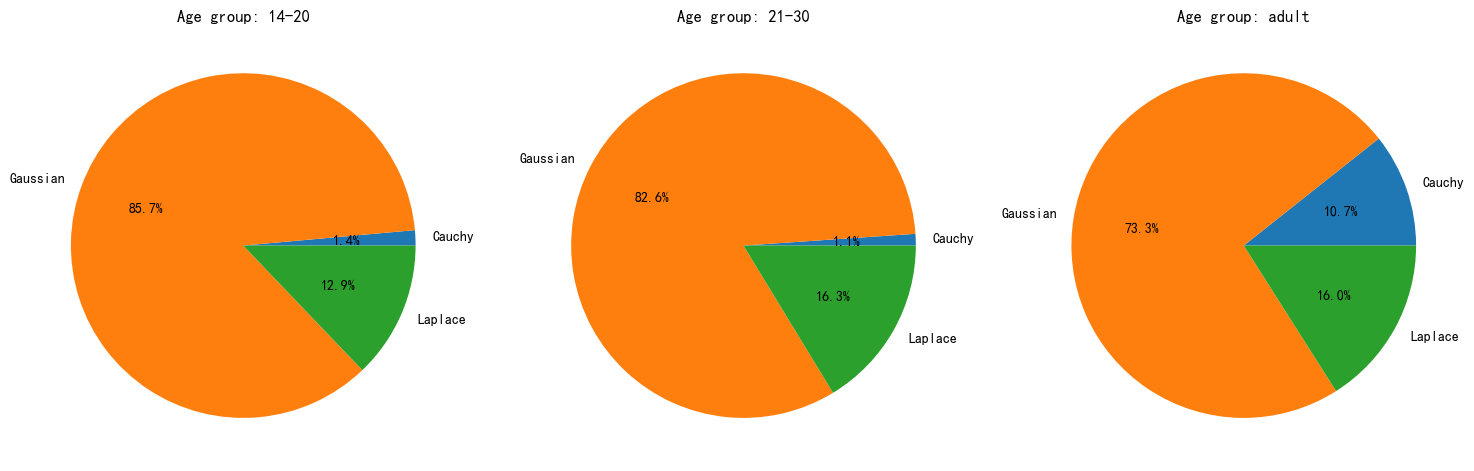

In [474]:
import matplotlib.pyplot as plt

# 获取所有年龄组
age_groups = model_counts['age_group'].unique()

fig, axes = plt.subplots(1, len(age_groups), figsize=(5*len(age_groups), 5))

# 如果只有一个年龄组，axes 不是数组，需要处理
if len(age_groups) == 1:
    axes = [axes]

for ax, age in zip(axes, age_groups):
    subset = model_counts[model_counts['age_group'] == age]
    
    ax.pie(subset['count'],
           labels=subset['best_model'],
           autopct='%1.1f%%')
    
    ax.set_title(f'Age group: {age}')

plt.tight_layout()
plt.show()

In [475]:
# 统计每个年龄组的神经元数量
neuron_counts = df.groupby('age_group')['neuro_id'].nunique().reset_index()

neuron_counts.columns = ['age_group', 'n_neurons']

print(neuron_counts)

  age_group  n_neurons
0     14-20         71
1     21-30         92
2     adult         75


C:\Users\刘炜\AppData\Local\Temp\ipykernel_18436\513111253.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='age_group', y='FWHM', data=combined_df, ax=axes[0], palette='Set2')
C:\Users\刘炜\AppData\Local\Temp\ipykernel_18436\513111253.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='age_group', y='FWHM_raw', data=combined_df, ax=axes[1], palette='Set2')


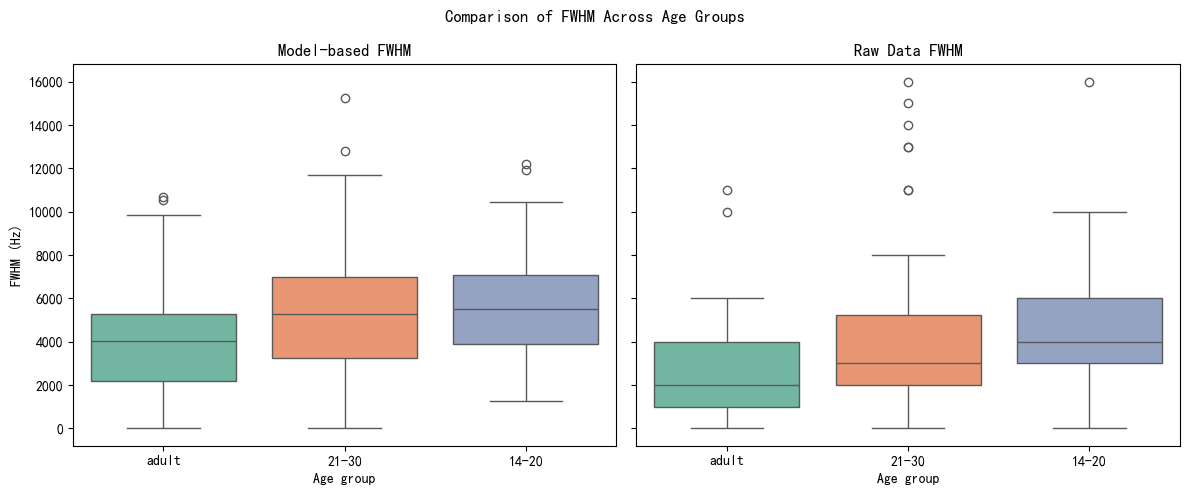

In [479]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# 1️⃣ 计算模型 FWHM
# -------------------------------
def compute_fwhm(row):
    if row['best_model'] == 'Gaussian':
        return 2.355 * row['width']
    elif row['best_model'] == 'Cauchy':
        return 2 * row['width']
    else:  # Laplace
        return 2 * row['width'] * np.log(2)

neuron_fit_df['FWHM'] = neuron_fit_df.apply(compute_fwhm, axis=1)

# -------------------------------
# 2️⃣ 从原始数据计算 FWHM
# -------------------------------
def fwhm_from_raw(neuron_df):
    freqs = neuron_df['frequency'].values
    fr = neuron_df['normalized_fr'].values
    peak = fr.max()
    half_max = peak / 2

    indices = np.where(fr >= half_max)[0]
    if len(indices) == 0:
        return np.nan
    left_idx = indices[0]
    right_idx = indices[-1]
    fwhm = freqs[right_idx] - freqs[left_idx]
    return fwhm

raw_fwhm_list = []
for neuron_id, neuron_df_group in df.groupby('neuro_id'):
    fwhm_raw = fwhm_from_raw(neuron_df_group)
    raw_fwhm_list.append({
        'neuro_id': neuron_id,
        'age_group': neuron_df_group['age_group'].iloc[0],
        'FWHM_raw': fwhm_raw
    })

raw_fwhm_df = pd.DataFrame(raw_fwhm_list)

# -------------------------------
# 3️⃣ 合并数据
# -------------------------------
combined_df = neuron_fit_df.merge(raw_fwhm_df, on=['neuro_id', 'age_group'])

# -------------------------------
# 4️⃣ 绘制箱线图
# -------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12,5), sharey=True)

# 模型 FWHM
sns.boxplot(x='age_group', y='FWHM', data=combined_df, ax=axes[0], palette='Set2')
axes[0].set_title('Model-based FWHM')
axes[0].set_xlabel('Age group')
axes[0].set_ylabel('FWHM (Hz)')

# 原始数据 FWHM
sns.boxplot(x='age_group', y='FWHM_raw', data=combined_df, ax=axes[1], palette='Set2')
axes[1].set_title('Raw Data FWHM')
axes[1].set_xlabel('Age group')

plt.suptitle("Comparison of FWHM Across Age Groups")
plt.tight_layout()
plt.show()